# Part 1: Playing with tabular data. The Iris Dataset.

The Iris dataset is a well-known and frequently used dataset in the field of machine learning and statistics. It was introduced by British biologist and statistician Ronald A. Fisher in 1936. The dataset consists of samples from three different species of Iris flowers, namely Setosa, Versicolor, and Virginica. Each species is represented by 50 samples, resulting in a total of 150 data points.

**Features**: The dataset contains four features (attributes) for each sample:

1. Sepal Length (in centimeters)
2. Sepal Width (in centimeters)
3. Petal Length (in centimeters)
4. Petal Width (in centimeters)

**Target Variable**: There is one target variable representing the species of each Iris flower sample. The target variable consists of three classes:
- Setosa (Class 0)
- Versicolor (Class 1)
- Virginica (Class 2)


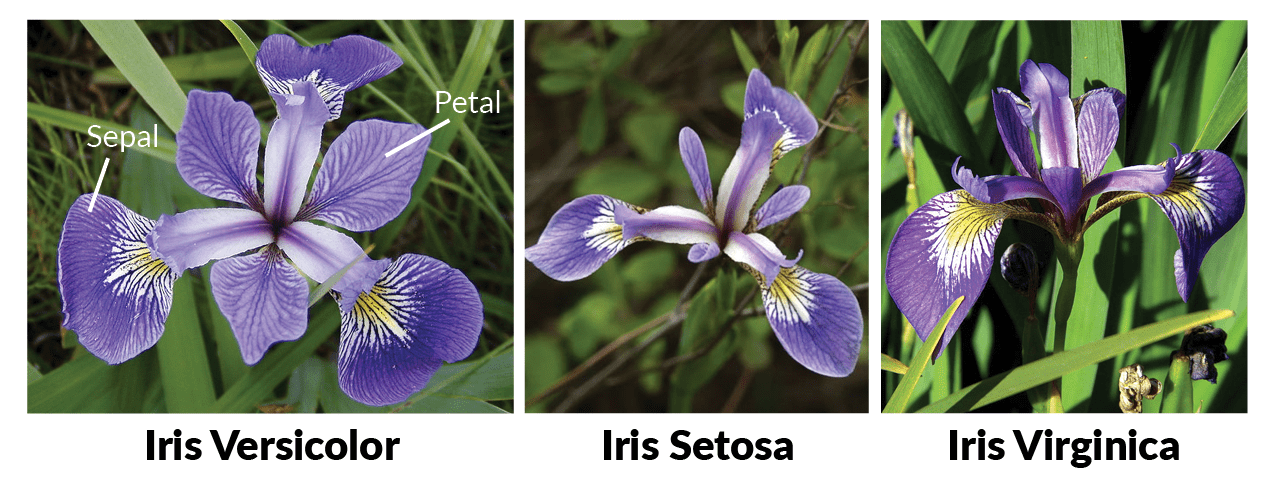

## Exercise 1: Load and understand the data.

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


Download the dataset in csv format. (https://www.kaggle.com/datasets/arshid/iris-flower-dataset)

Load the dataset into a variable **iris**

In [3]:
iris_data = np.genfromtxt('IRIS.csv', delimiter=',', skip_header=1, dtype=str)

iris_numbers = iris_data[:, :-1].astype(float)
species = iris_data[:, -1]

print(iris_numbers)
print(species)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

Now create a function that plots two of the columns of the dataset (e.g. sepal length vs petal length) in a [scatter plot](https://matplotlib.org/stable/gallery/shapes_and_collections/scatter.html#sphx-glr-gallery-shapes-and-collections-scatter-py).

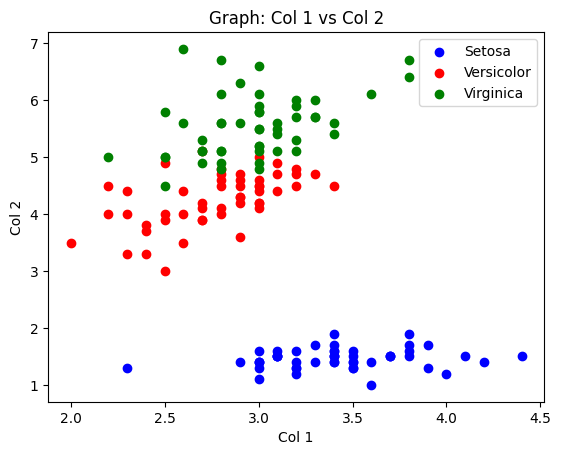

In [4]:

def plot(col_x, col_y):
    # Gráfico individual para una combinación (col_x, col_y)
    setosaX = iris_numbers[0:50, col_x]
    setosaY = iris_numbers[0:50, col_y]
    plt.scatter(setosaX, setosaY, c="blue", label="Setosa")

    versicolorX = iris_numbers[50:100, col_x]
    versicolorY = iris_numbers[50:100, col_y]
    plt.scatter(versicolorX, versicolorY, c="red", label="Versicolor")

    virginicaX = iris_numbers[100:150, col_x]
    virginicaY = iris_numbers[100:150, col_y]
    plt.scatter(virginicaX, virginicaY, c="green", label="Virginica")

    plt.xlabel(f"Col {col_x}")
    plt.ylabel(f"Col {col_y}")
    plt.legend()
    plt.title(f"Graph: Col {col_x} vs Col {col_y}")
    plt.show()

plot(1,2)


With the function you implemented before, now visualize all the 6 combinations of features.

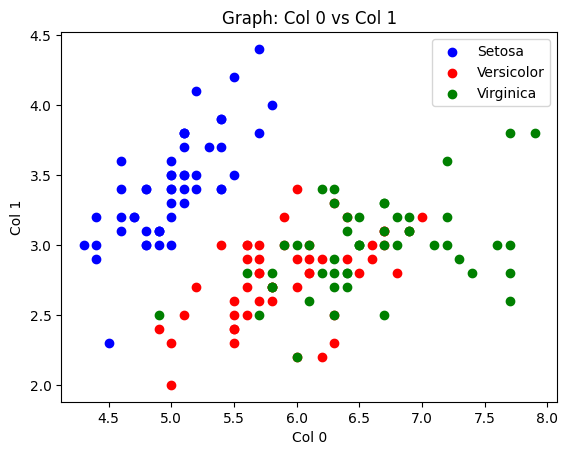

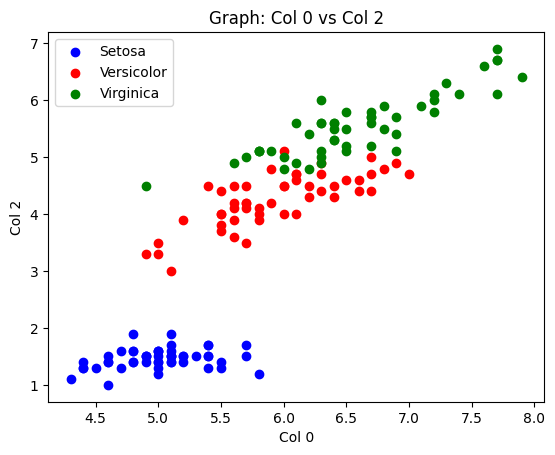

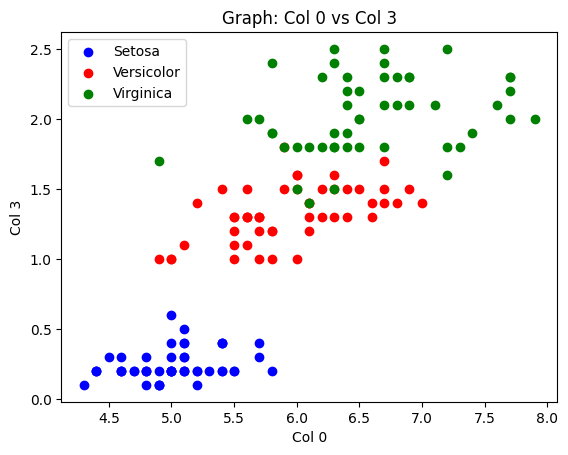

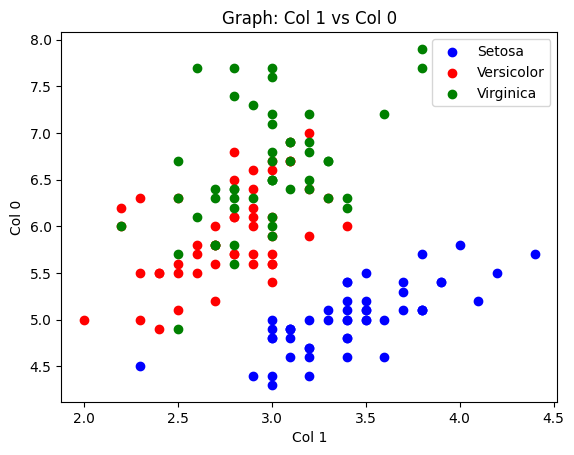

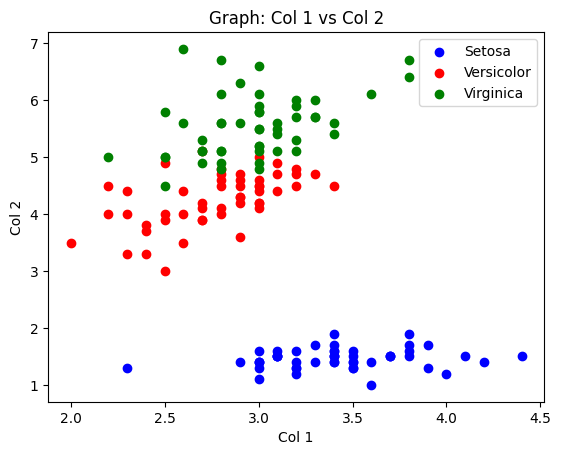

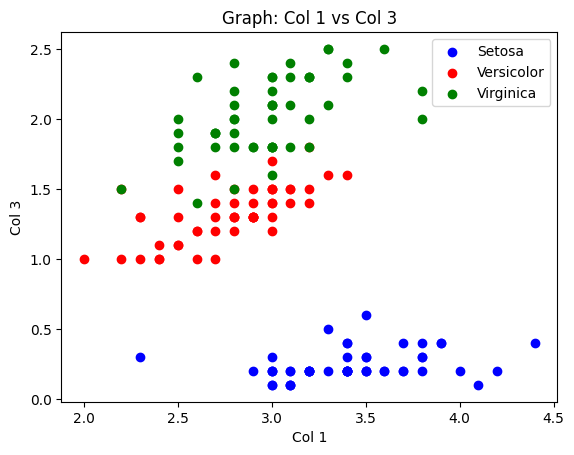

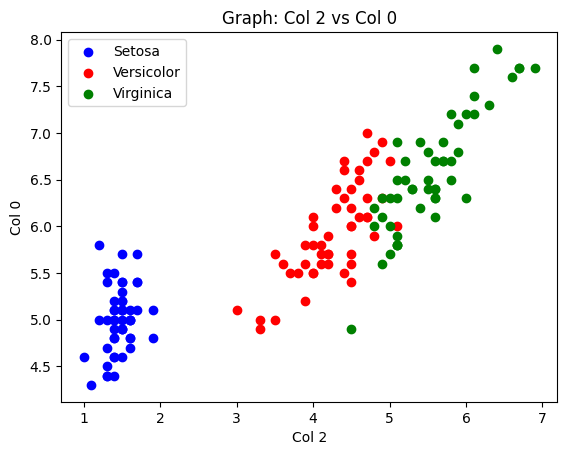

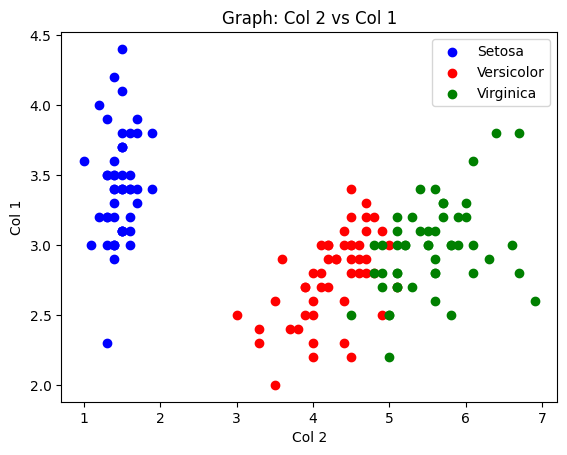

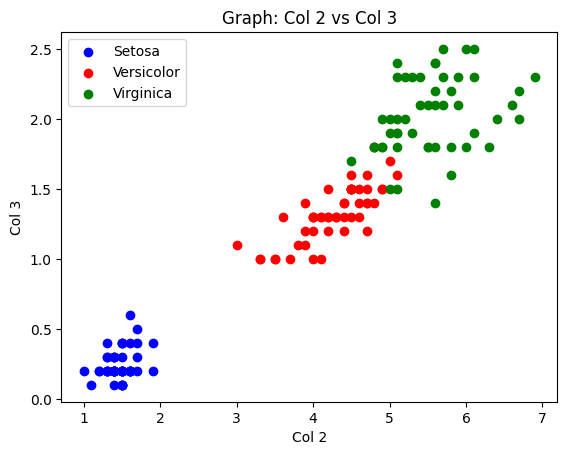

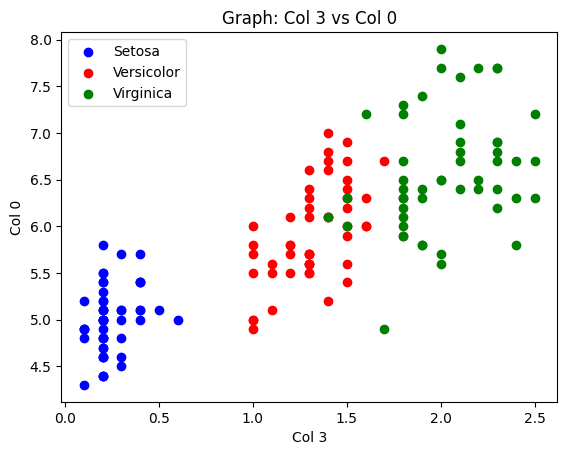

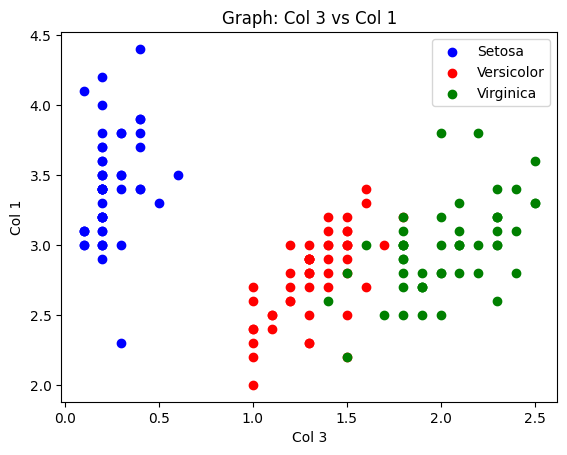

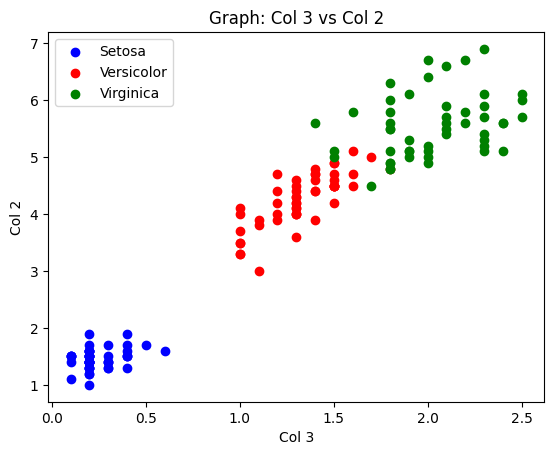

In [5]:
def allPlots():
    for i in range(0, 4):      
        for j in range(0, 4):
            if i != j:         
                plot(i, j)
allPlots()

## Excercise 2 - using the dataset

Split the dataset in X (features) and Y (labels).

In [6]:
from sklearn import datasets
iris = datasets.load_iris()

X = iris.data
y = iris.target

Then create a function that splits into train/ test based on % amount. (shuffle to dont use 1 type of flower on train)

In [7]:
def split_train_test(X, y, train_percent):
    # Combine and shuffle the data
    indexs = np.arange(len(X))
    np.random.shuffle(indexs)

    # Split based on percentage
    split_point = int(train_percent * len(X))
    train_idx = indexs[:split_point]
    test_idx = indexs[split_point:]

    # Create splits
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

# Example usage:
X_train, X_test, y_train, y_test = split_train_test(X, y, 0.7)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 105
Test size: 45


Use the function created previously to split the data so that we can use the 70% of data for training and the 30% for testing.

In [8]:
X_train, X_test, y_train, y_test = split_train_test(X, y, 0.7)

### Logistic Regression
Let's first train a Logistic Regression model (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression).

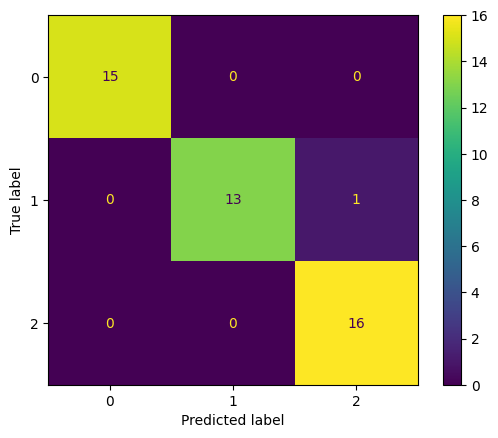

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train,y_train)
prediction = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, prediction)

### Decision Tree

Let's now train a DecisionTreeClassifier (https://scikit-learn.org/stable/modules/tree.html#decision-trees). We will train it, predict the test set, visualize the classification tree and its confusion matrix.

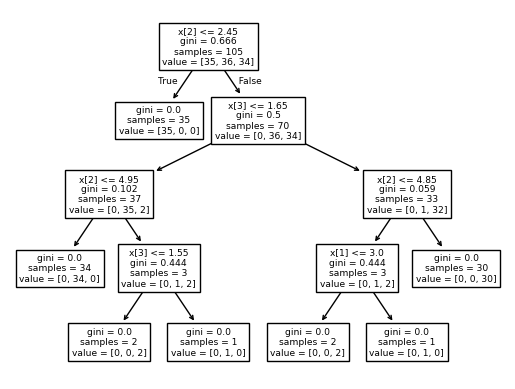

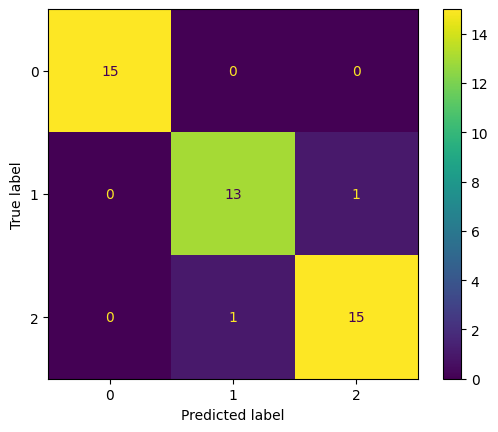

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

plot_tree(clf)
ConfusionMatrixDisplay.from_predictions(y_test,prediction)

### Forests


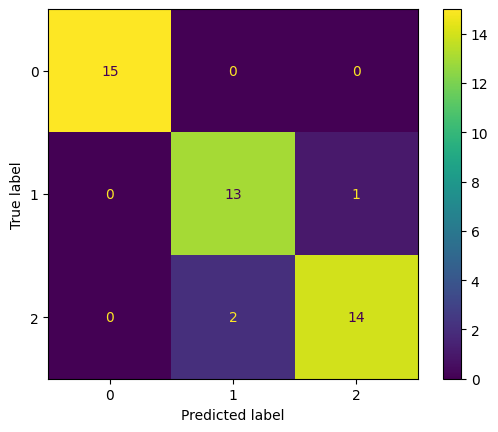

In [11]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test,prediction)

### SVM

Let's now train a SVM classifier (https://scikit-learn.org/stable/modules/svm.html#svm). We will train it, predict the test set and its confusion matrix.

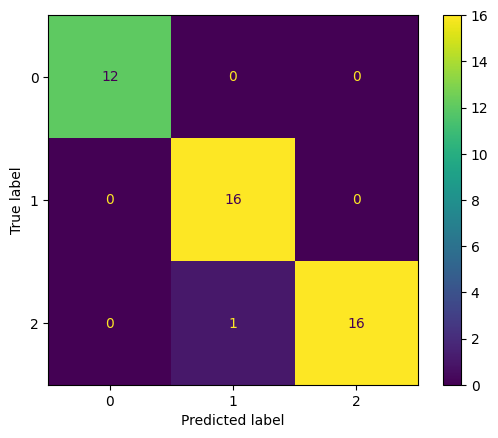

In [103]:
from sklearn import svm

clf = svm.SVC()
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, prediction)